# (1) Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# (2) Load Dataset

In [ ]:
df=pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\NYC.csv\NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# (3) Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


# (4) Shape

In [ ]:
print(df.shape)

(1458644, 11)


# (5) Missing Values

In [ ]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

# (6) Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop_duplicates()

# (7) Statistical Summary

In [ ]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


## EDA

# Target distribution

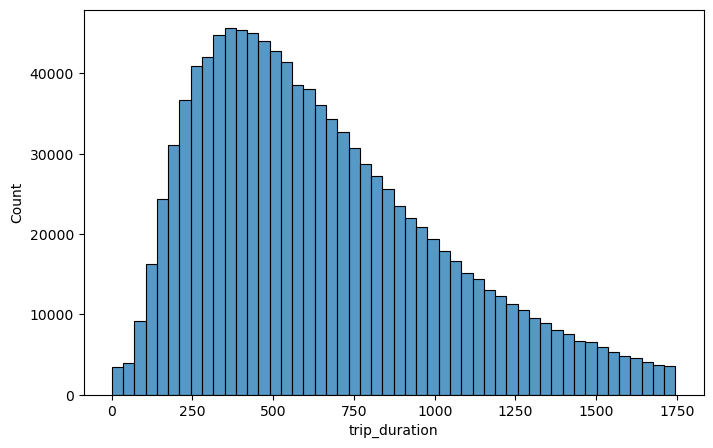

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['trip_duration'],bins=50)

plt.show()

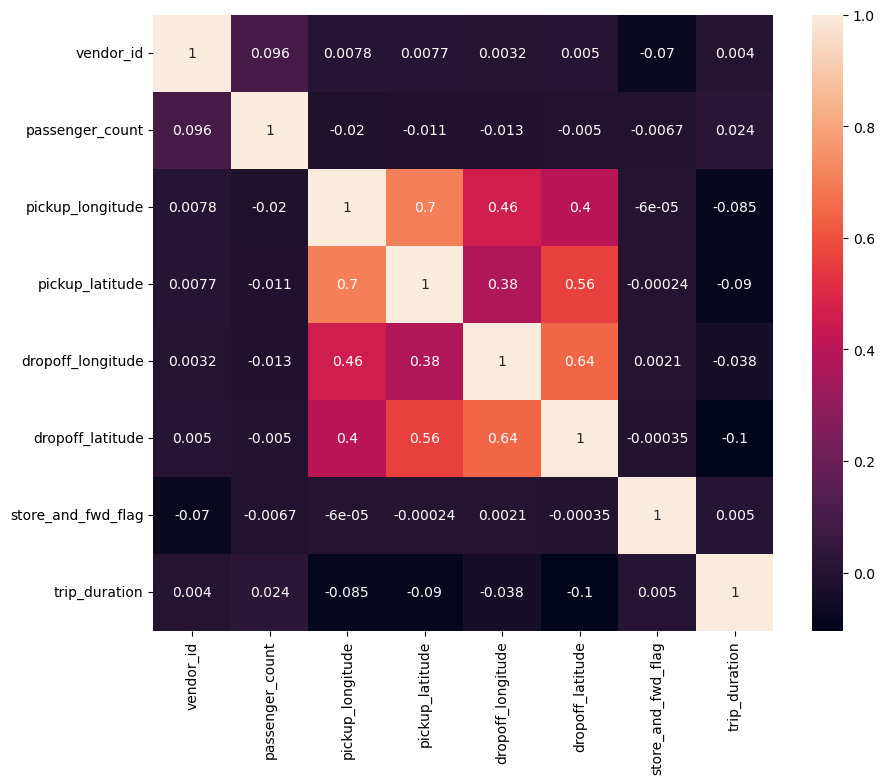

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
df.select_dtypes(include=np.number).corr(),
annot=True
)

plt.show()

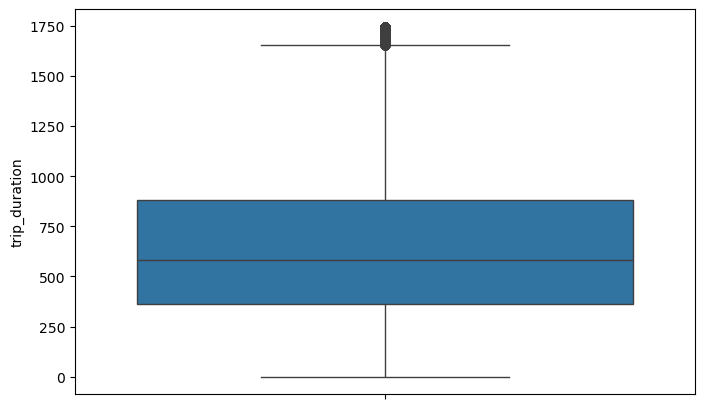

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(df['trip_duration'])

plt.show()

# Outlier Removal (IQR Method)

In [ ]:
df=df[
(df['trip_duration']>=lower)
&
(df['trip_duration']<=upper)
].copy()

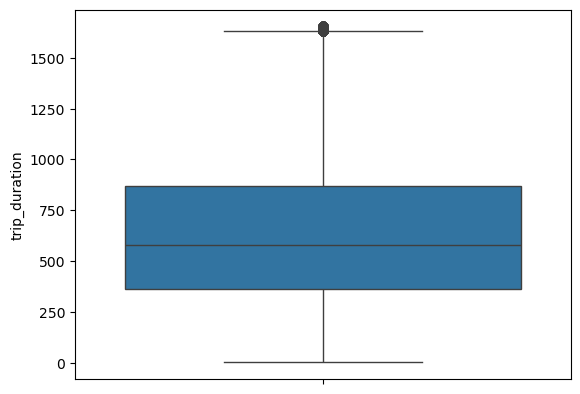

In [ ]:
sns.boxplot(df['trip_duration'])

plt.show()

# Feature Engineering

In [ ]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

C:\Users\Aamir choudhary\AppData\Local\Temp\ipykernel_9504\2714565495.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])


In [ ]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

df['pickup_hour']=df['pickup_datetime'].dt.hour

df['pickup_day']=df['pickup_datetime'].dt.day

df['pickup_month']=df['pickup_datetime'].dt.month

df['pickup_weekday']=df['pickup_datetime'].dt.weekday

In [ ]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_weekday
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,14,3,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,12,6,6
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,6,4,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,26,3,5
8,id1301050,1,2016-05-27 23:12:23,2016-05-27 23:16:38,1,-73.999481,40.738400,-73.985786,40.732815,0,255,23,27,5,4


In [ ]:
from math import radians,sin,cos,sqrt,atan2

def haversine(lat1,lon1,lat2,lon2):

    R=6371

    lat1,lon1,lat2,lon2=map(
        radians,
        [lat1,lon1,lat2,lon2]
    )

    dlat=lat2-lat1
    dlon=lon2-lon1

    a=sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2

    return 2*R*atan2(
        sqrt(a),
        sqrt(1-a)
    )

df['distance']=df.apply(
lambda x:
haversine(
x['pickup_latitude'],
x['pickup_longitude'],
x['dropoff_latitude'],
x['dropoff_longitude']
),
axis=1
)

# Drop unnecessary columns:

In [ ]:
df=df.drop([
'id',
'pickup_datetime',
'dropoff_datetime'
],axis=1)

# Encoding

In [ ]:
le=LabelEncoder()

df['store_and_fwd_flag']=le.fit_transform(
df['store_and_fwd_flag']
)

# Separate X and Y

In [ ]:
X=df.drop('trip_duration',axis=1)

y=df['trip_duration']

# Train Test Split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Regression Model

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)
pred1=lr.predict(X_test)

print("Linear R2:",r2_score(y_test,pred1))

Linear R2: 0.46901832797760157


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt.fit(X_train,y_train)

pred=dt.predict(X_test)

# Evaluation

In [ ]:
print("R2:",r2_score(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

R2: 0.6059042566422002
MAE: 170.50690054945565
RMSE: 225.49753490900233


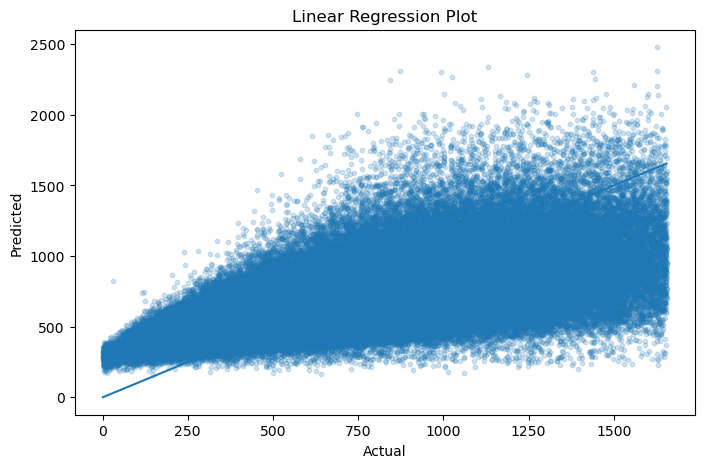

In [ ]:
lr=LinearRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred_lr,
    alpha=0.2,
    s=10
)

plt.plot(
[y_test.min(),y_test.max()],
[y_test.min(),y_test.max()]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Plot")

plt.show()